# 09 · Does the "€100 → Gold tier" perk retain people? — RDD (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** Customers who cross **€100** annual spend get **Gold** status and its perks.
Gold members retain better — but of course they do, they're big spenders. Does the *perk itself* boost
retention, or are we just seeing that big spenders would retain anyway? And where should we set the
threshold?

### The idea: a sharp rule creates a natural experiment

**Regression discontinuity (RDD)** exploits the fact that Gold status is assigned by a **sharp rule** on a
**running variable** (annual spend): below €100 you're out, at €100-or-above you're in. Now compare a
customer at €99.50 with one at €100.50. On *retention potential* they are essentially identical — nobody
is meaningfully more loyal for having spent one euro more. The *only* thing that differs between them is
that one got the perk and one didn't. So **any jump in retention exactly at €100** must be caused by the
perk, not by the underlying "big spenders retain more" trend (which is smooth through the cutoff). RDD
reads off the size of that jump.

### What it can and can't tell you

- It estimates a **LATE at the cutoff** — the perk's effect *for customers near €100* (here *local* means local-to-the-cutoff: an ATE exactly at €100, **not** the complier-LATE of a fuzzy design). It says nothing
  about your €500 whales; don't extrapolate the jump to them.
- It's only valid if customers can't **manipulate** their spend to just clear €100 (that would make the
  people just above and just below systematically different). We test this with a **simplified McCrary-style** density check (a symmetric-window binomial test for a suspicious
  pile-up of customers just above the cutoff; the full McCrary 2008 test fits a local-linear density with a Wald SE).
- A headline RD number is only as good as its **robustness checks**: does the jump survive different
  **bandwidths** (how wide a window around €100 we use), **placebo cutoffs** (fake thresholds should show
  no jump), and **polynomial order** (linear vs curved fits)? We run all of them.

> **On real data.** RDD fits anywhere a **threshold rule** assigns a treatment: loyalty tiers, credit-score
> cutoffs for an offer, "spend €X for free shipping," scholarship/eligibility scores. You need the running
> variable, the cutoff, and the outcome — all of which live in your CRM.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 29; CUTOFF = 100.0; TRUE = 0.14

## 2 · Simulate a ground truth

Retention rises smoothly with annual spend (big spenders retain more anyway) — **plus** a true
**+14pp jump** exactly at €100 from the Gold perk. The smooth part is the confounder; the jump is
the causal effect. Spend is concentrated around the cutoff so both sides are well-populated.


In [2]:
df, true_jump = dgp.rdd_perk(n=2500, cutoff=CUTOFF, true_jump=TRUE, seed=SEED)
df["treated"] = df["treated"].astype(int)
print(f"TRUE perk effect = +{true_jump:.0%} retention at €{CUTOFF:.0f}  ·  {(df.spend>=CUTOFF).mean():.0%} are Gold")
df.head()

TRUE perk effect = +14% retention at €100  ·  50% are Gold


,spend,treated,retention
0,84.325206,0,1.0
1,101.996816,1,0.0
2,93.392393,0,1.0
3,93.281224,0,0.0
4,102.504635,1,0.0


## 3 · Identify — a jump at the cutoff is causal (and its validity conditions)

**Sharp RD estimand:**
$\tau_{RD}=\lim_{x\downarrow c}\mathbb E[Y\mid X{=}x]-\lim_{x\uparrow c}\mathbb E[Y\mid X{=}x]$ —
the discontinuity in retention at spend $=€100$. **Identification:** potential-outcome means are
*continuous* at the cutoff, so units just either side are comparable and the jump is causal. This
is a **LATE at the cutoff** — local to €100 (*local* = local-to-the-cutoff, i.e. an ATE exactly at €100, **not** the complier-LATE of a fuzzy design). Two things must hold, both checked below:

- **No manipulation** of the running variable at the cutoff (customers/business can't sort across
  it) — a simplified McCrary-style density check (a symmetric-window binomial test).
- **The functional form isn't driving the jump** — checked via bandwidth, placebo cutoffs, and
  polynomial order.


## 3b · Validity check 1 — McCrary-style density check (manipulation)

If customers game their spend to just clear €100 (or the business nudges them), the *density* of
spend jumps at the cutoff and RD breaks. We compare the density just below vs just above with a symmetric-window binomial test. (This is a
*simplified* version; the full McCrary 2008 test fits a local-linear density on each side with a Wald SE.)


density just below 23.7 vs above 24.0, log-ratio +0.01, binomial z +0.15 — no significant sorting across the cutoff (|z| < 2).


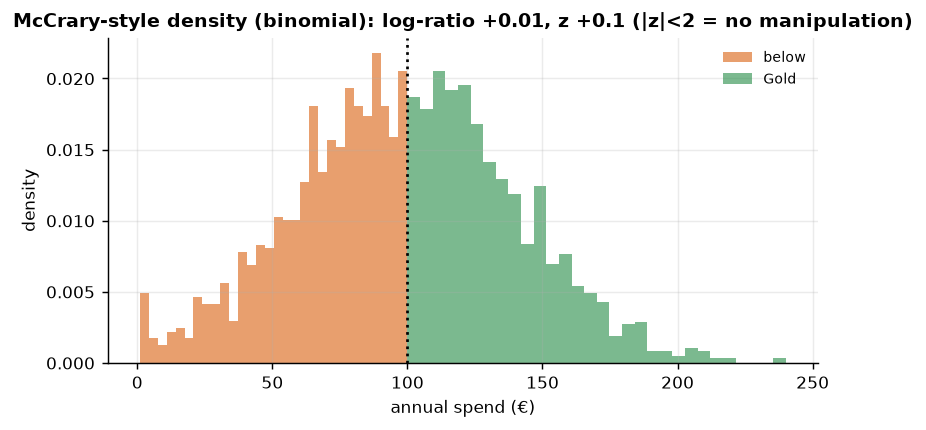

In [3]:
d_below, d_above, log_ratio, z_mcc = est.mccrary_density(df.spend.values, CUTOFF, bandwidth=15)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(df.spend[df.spend < CUTOFF], bins=30, color=plots.ORANGE, alpha=0.6, density=True, label="below")
ax.hist(df.spend[df.spend >= CUTOFF], bins=30, color=plots.GREEN, alpha=0.6, density=True, label="Gold")
ax.axvline(CUTOFF, color="k", ls=":"); ax.set_xlabel("annual spend (€)"); ax.set_ylabel("density")
ax.set_title(f"McCrary-style density (binomial): log-ratio {log_ratio:+.2f}, z {z_mcc:+.1f} (|z|<2 = no manipulation)"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"density just below {d_below:.1f} vs above {d_above:.1f}, log-ratio {log_ratio:+.2f}, binomial z {z_mcc:+.2f} — "
      + ("no significant sorting across the cutoff (|z| < 2)." if abs(z_mcc) < 2 else "SIGNIFICANT pile-up — possible manipulation!"))

(The density is smooth through €100 — no suspicious pile-up of customers *just* above the cutoff — so we
have no evidence of manipulation, and the RDD comparison is fair.)

## 4 · Estimate — Bayesian regression discontinuity

Now the estimate itself. We fit a **local linear** regression on each side of the cutoff — a straight line
for the below-€100 customers and another for the Gold customers — and the **height of the step where they
meet at €100** is the causal effect of the perk. We restrict to a **bandwidth** of ±€40 around the cutoff:
the customers near the threshold are the comparable ones (a €98 and a €102 customer are alike; a €500 whale
is not). Wider bandwidths borrow non-comparable customers; narrower ones throw away data — Step 5 checks the
answer is stable to that choice.

We model retention with a local linear probability model — standard for RD jumps; a logit link changes nothing material because the fit is local.

In [4]:
result = est.rdd(df[["spend","retention","treated"]], formula="retention ~ 1 + spend + treated + spend:treated",
                 running_variable_name="spend", treatment_threshold=CUTOFF, bandwidth=40.0, fast=FAST)
jump = np.asarray(result.discontinuity_at_threshold).ravel()
print(f"RD jump +{jump.mean():.1%} (true +{true_jump:.0%})  ·  90% credible interval [+{np.quantile(jump,0.05):.1%}, +{np.quantile(jump,0.95):.1%}]")
print(f"RDD convergence: {est.convergence_report(result.idata)["summary"]}")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


RD jump +11.3% (true +14%)  ·  90% credible interval [+3.8%, +18.7%]
RDD convergence: max r-hat 1.000 - min ESS 1378 - divergences 0


## 5 · Validate — see the jump, plus bandwidth / placebo / polynomial robustness

A credible RD number is one that **survives** the researcher-degrees-of-freedom checks:

- **Bandwidth curve** — the estimate should be stable across a sensible range of bandwidths.
- **Placebo cutoffs** — run RD at fake thresholds (€70, €80, €120, €130) where there's no perk; the jump
  should be ≈ 0. A real jump at a fake cutoff would mean the method finds discontinuities in noise.
- **Polynomial order** — linear vs quadratic local fit shouldn't move the answer much.


Bandwidth sweep: +7.2% … +14.9% across bw 15–60 (mean +12.0%) — drifts mildly but stays clearly positive.
Polynomial: linear +11.3%, quadratic +10.9%.
Placebo cutoffs (jump, t-stat): €70 +0.6% (t=+0.09), €80 -1.2% (t=-0.20), €120 +0.9% (t=+0.15), €130 +5.8% (t=+0.90)
Largest placebo |t| = 0.90 — all statistically indistinguishable from zero; the real €100 jump's 90% CrI [+3.8%, +18.7%] excludes zero.


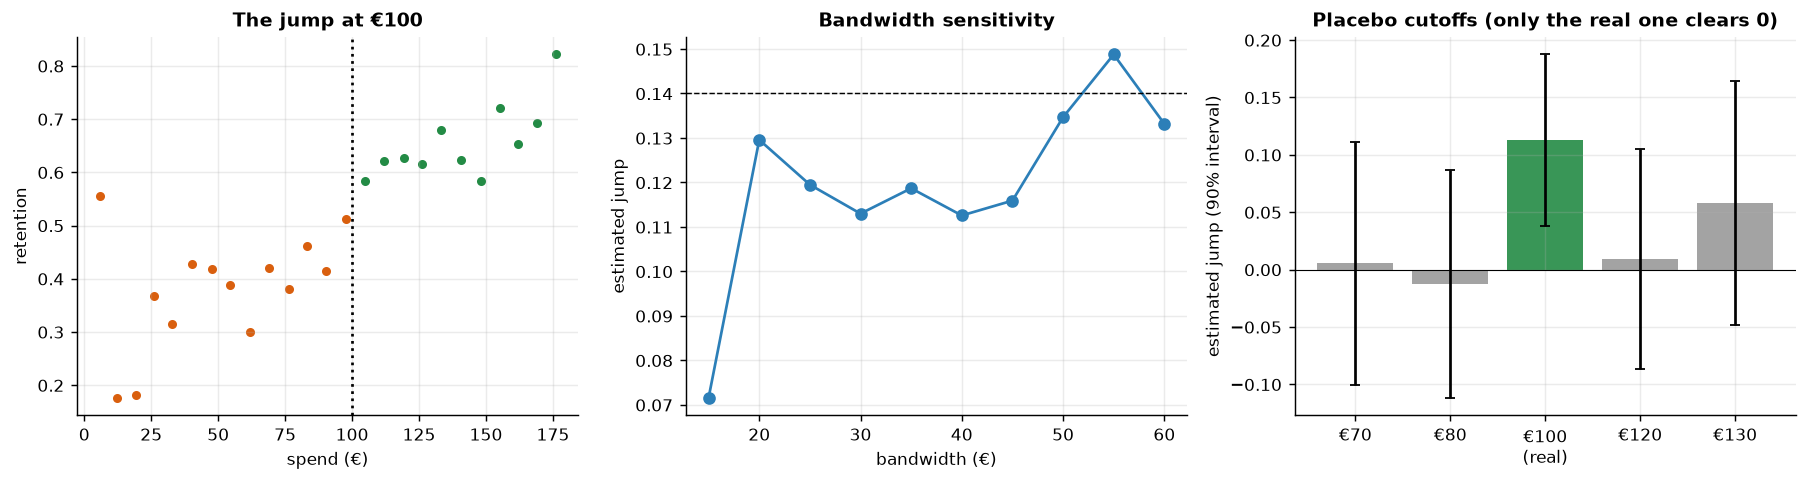

In [5]:
def rd_jump(data, cutoff, bw, order=1):
    """Local polynomial RD jump at `cutoff` within ±bw. Returns the estimated
    discontinuity (the coefficient on the 'treated' indicator) AND its classical
    OLS standard error, so a placebo jump can be judged against zero with a
    t-stat rather than eyeballed."""
    sub = data[np.abs(data.spend - cutoff) <= bw].copy()
    x = (sub.spend - cutoff).values; tr = (sub.spend >= cutoff).astype(float).values; y = sub.retention.values
    cols = [np.ones(len(x)), tr, x, x*tr]
    if order == 2: cols += [x**2, x**2*tr]
    D = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(D, y, rcond=None)
    resid = y - D @ beta; n, k = D.shape
    cov = (resid @ resid / max(n - k, 1)) * np.linalg.pinv(D.T @ D)
    return float(beta[1]), float(np.sqrt(max(cov[1, 1], 0.0)))   # (jump, SE of the jump)

bws = np.arange(15, 61, 5)
by_bw = [rd_jump(df, CUTOFF, b)[0] for b in bws]
placebo_cuts = [70, 80, 120, 130]
placebos = {c: rd_jump(df, c, 25) for c in placebo_cuts}                 # (jump, SE) per fake cutoff
poly = {"linear": rd_jump(df, CUTOFF, 40, 1), "quadratic": rd_jump(df, CUTOFF, 40, 2)}
z90 = 1.645

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
# binned scatter
bins = np.linspace(df.spend.min(), min(df.spend.max(), 180), 26); df["bin"] = pd.cut(df.spend, bins)
b = df.groupby("bin", observed=True).agg(spend=("spend","mean"), ret=("retention","mean")).dropna()
below = b.spend < CUTOFF
ax[0].scatter(b.spend[below], b.ret[below], color=plots.ORANGE, s=16); ax[0].scatter(b.spend[~below], b.ret[~below], color=plots.GREEN, s=16)
ax[0].axvline(CUTOFF, color="k", ls=":"); ax[0].set_xlabel("spend (€)"); ax[0].set_ylabel("retention"); ax[0].set_title("The jump at €100")
# bandwidth curve
ax[1].plot(bws, by_bw, color=plots.BLUE, marker="o"); ax[1].axhline(true_jump, color="k", ls="--", lw=0.8)
ax[1].set_xlabel("bandwidth (€)"); ax[1].set_ylabel("estimated jump"); ax[1].set_title("Bandwidth sensitivity")
# placebo cutoffs WITH 90% intervals — real cutoff = CausalPy posterior CI; placebos = local-linear ±1.645·SE
real_lo, real_hi = np.quantile(jump, 0.05), np.quantile(jump, 0.95)
labels = ["€70","€80","€100\n(real)","€120","€130"]
vals   = [placebos[70][0], placebos[80][0], jump.mean(), placebos[120][0], placebos[130][0]]
err_lo = [z90*placebos[70][1], z90*placebos[80][1], jump.mean()-real_lo, z90*placebos[120][1], z90*placebos[130][1]]
err_hi = [z90*placebos[70][1], z90*placebos[80][1], real_hi-jump.mean(), z90*placebos[120][1], z90*placebos[130][1]]
ax[2].bar(labels, vals, yerr=[err_lo, err_hi], capsize=3, color=[plots.GREY]*2+[plots.GREEN]+[plots.GREY]*2, alpha=0.9)
ax[2].axhline(0, color="k", lw=0.6); ax[2].set_ylabel("estimated jump (90% interval)"); ax[2].set_title("Placebo cutoffs (only the real one clears 0)")
fig.tight_layout()
placebo_t = {c: placebos[c][0] / placebos[c][1] for c in placebo_cuts}
max_t = max(abs(t) for t in placebo_t.values())
print(f"Bandwidth sweep: +{min(by_bw):.1%} … +{max(by_bw):.1%} across bw {bws.min()}–{bws.max()} "
      f"(mean +{np.mean(by_bw):.1%}) — drifts mildly but stays clearly positive.")
print(f"Polynomial: linear +{poly['linear'][0]:.1%}, quadratic +{poly['quadratic'][0]:.1%}.")
print("Placebo cutoffs (jump, t-stat): " + ", ".join(f"€{c} {placebos[c][0]:+.1%} (t={placebo_t[c]:+.2f})" for c in placebo_cuts))
print(f"Largest placebo |t| = {max_t:.2f} — all statistically indistinguishable from zero; the real €100 jump's "
      f"90% CrI [+{real_lo:.1%}, +{real_hi:.1%}] excludes zero.")

**How to read the robustness battery.** *Left* — bin retention by spend and you can *see* the step at €100
sitting on top of the smooth "big spenders retain more" trend; that step is the perk effect. *Middle* — the
estimate **drifts mildly** with the bandwidth (narrow windows are noisier, wider ones pull in curvature) but
stays clearly positive and brackets the truth across the whole range, so we're not cherry-picking a window.
*Right* — the decisive check, now **with 90% intervals**: re-run the same local-linear RD at **fake** cutoffs
(€70, €80, €120, €130) where no perk exists. Their point estimates wobble around zero — the €130 placebo is
the largest, but read its *interval*, not its bar height: it comfortably spans zero (small-sample wobble in a
thinner slice of data), and every placebo's |t| is well under 2. Only the **real** €100 cutoff has an
interval that **excludes** zero. That is the honest test — a *t*-stat, not the eyeball. Together with the
McCrary density and the linear-vs-quadratic agreement, it's the full case that the jump is a real causal
effect, not an artefact of how we drew the lines.

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each) and check both.

RD jump across 25 seeds: mean +13.8% (true +14%)  bias -0.2%  sd 4.3%  ·  90% CI covers truth in 23/25 seeds — near-nominal calibration.


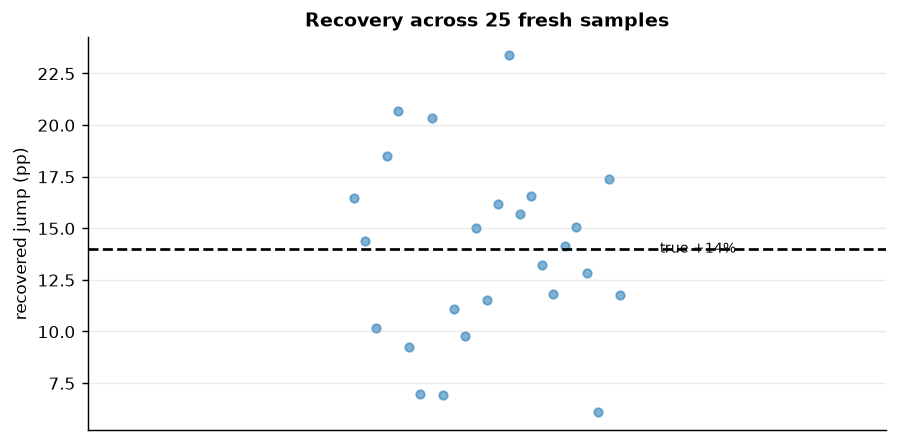

In [6]:
# --- Recovery across many seeds: does the RD jump recover +14pp and cover it? (fast OLS local-linear) ---
NSEED = 12 if FAST else 25
pts = []; cov = 0; z90 = 1.645
for sd in range(NSEED):
    d, tj = dgp.rdd_perk(n=2500, cutoff=CUTOFF, true_jump=TRUE, seed=200 + sd)
    d["treated"] = d["treated"].astype(int)
    j, se = rd_jump(d, CUTOFF, 40, 1)
    pts.append(j); cov += int(abs(j - tj) <= z90 * se)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts * 100, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(TRUE * 100, color="k", ls="--"); ax.text(0.26, TRUE * 100, f"true +{TRUE:.0%}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered jump (pp)")
ax.set_title(f"Recovery across {NSEED} fresh samples"); fig.tight_layout()
print(f"RD jump across {NSEED} seeds: mean +{pts.mean():.1%} (true +{TRUE:.0%})  bias {pts.mean()-TRUE:+.1%}  "
      f"sd {pts.std():.1%}  ·  90% CI covers truth in {cov}/{NSEED} seeds — near-nominal calibration.")

## 6 · Decide, in euros — does the perk pay, and where to set the cutoff?

Value the retention lift: extra retained customers × annual value, minus the perk cost, **at the
current €100 margin** (that's what RD identifies). We also sweep the perk cost to find the
break-even.


Net €7.7/member  ·  total €22,960 [90% €-22,140, €67,444]
P(perk pays) 0.80 → reconsider  ·  break-even perk cost ≈ €8/member (conservative).


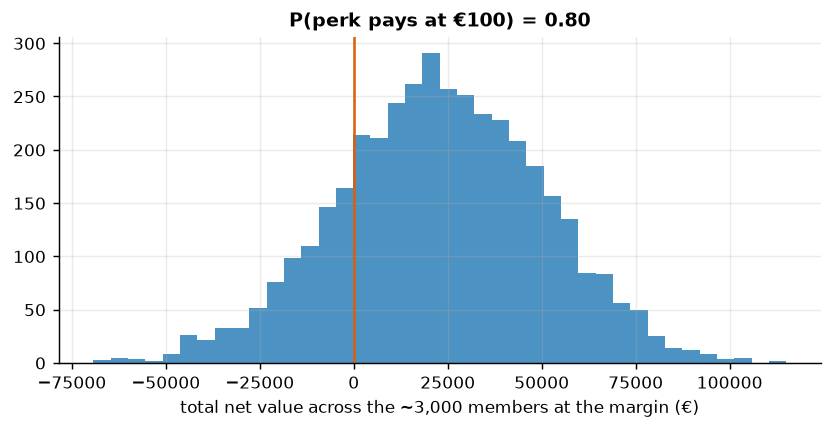

In [7]:
ANNUAL_VALUE, PERK_COST, N_AT_MARGIN = 200.0, 15.0, 3000
value = jump * ANNUAL_VALUE - PERK_COST
total = value * N_AT_MARGIN
p_worth = (value > 0).mean()
be_perk = np.quantile(jump, 0.05) * ANNUAL_VALUE      # perk cost the effect can bear (conservative)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(total, bins=40, color=plots.BLUE, alpha=0.85); ax.axvline(0, color=plots.ORANGE, lw=1.4)
ax.set_xlabel("total net value across the ~3,000 members at the margin (€)"); ax.set_title(f"P(perk pays at €100) = {p_worth:.2f}"); fig.tight_layout()
print(f"Net €{value.mean():.1f}/member  ·  total €{total.mean():,.0f} [90% €{np.quantile(total,0.05):,.0f}, €{np.quantile(total,0.95):,.0f}]")
print(f"P(perk pays) {p_worth:.2f} → " + ("KEEP / consider lowering cutoff" if p_worth>0.9 else "reconsider") +
      f"  ·  break-even perk cost ≈ €{be_perk:.0f}/member (conservative).")

**How to read the decision histogram.** Mass to the right of the orange zero line = P(perk pays); the wide spread — *not* the positive mean — is what makes this a *reconsider / TEST* call.

## 7 · Caveats

- **RD is *local*.** The effect is identified only *at the cutoff* — the perk's effect on customers
  near €100, not on your €500 whales. Don't extrapolate the jump to everyone.
- **Manipulation breaks it.** We checked the McCrary density; watch for heaping at round numbers.
- **Bandwidth is bias–variance.** The estimate drifts mildly with the window (narrow = noisier, wide =
  more curvature) but stays clearly positive here; an estimate that *swings across zero* with bandwidth
  would be a red flag.
- **Fuzzy RD if the rule isn't sharp.** If crossing €100 only *raises the probability* of Gold
  (grandfathering, overrides), use the fuzzy-RD ratio (jump in Y ÷ jump in P(treated)) — this ratio is exactly the Wald/IV estimator of notebook 11, with the threshold acting as the instrument.